
## Prueba Tercer Parcial

*Alan Solano*

### repositorio: https://github.com/ingealan/machinelearning1/blob/main/Examen_Tercer_parcial.ipynb

# Examen del Tercer Parcial 
## Regresión lineal
Dado el archivo **movie_genre_classification_final.csv** se encuentra un base de datos con información de **50000 películas** que incluyen variables como: <br>
 * Título,
 * Año de estreno,
 * Duración,
 * Puntuación promedio,
 * Número de votos,
 * Presupuesto,
 * Ingresos en taquilla,
 * Número de premios obtenidos,
 * Entre otras caracterisiticas.
Como parate del análisis de predicción, se desea estudiar la relación entre el:<br>
* Presupuesto de una película
y sus caracteristicas cuantitativas, para estimar la **recaudación en taquilla (BoxOffice_USD)**. Para ello, se plantea entrenar un modelo de regresión lineal.<br>

# Objetivo 
Predecir el valor de la variable **BoxOffice_USD** a partir de variables numéricas independientes disponibles en el dataset, tales como:<br>
* Budget_USD (Presupuesto en dólares)
* Duration (Duración en minutos)
* Ratting (Calificiación Promedio"
* Votes (Número de votos)
* Num_Awards (Número de premios obtenidos)
* Critic_reviews (Números de reseñas de criticos)

El dataset fue extraido desder <a href="https://www.kaggle.com/datasets/therohithanand/movie-genre-classification">DataSet<a> <br>

## Entrega esperada
* Código bien estructurado y comentado
* Gráficos claros en los pasos 2, 4 y 5.
* Breve análisis escrito de lso los resultados obtenidos.



In [1]:
# Lectura de datos
# Imports necesarios
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
# Importamos el csv
df= pd.read_csv("movie_genre_classification_final.csv")
df.shape

(50000, 17)

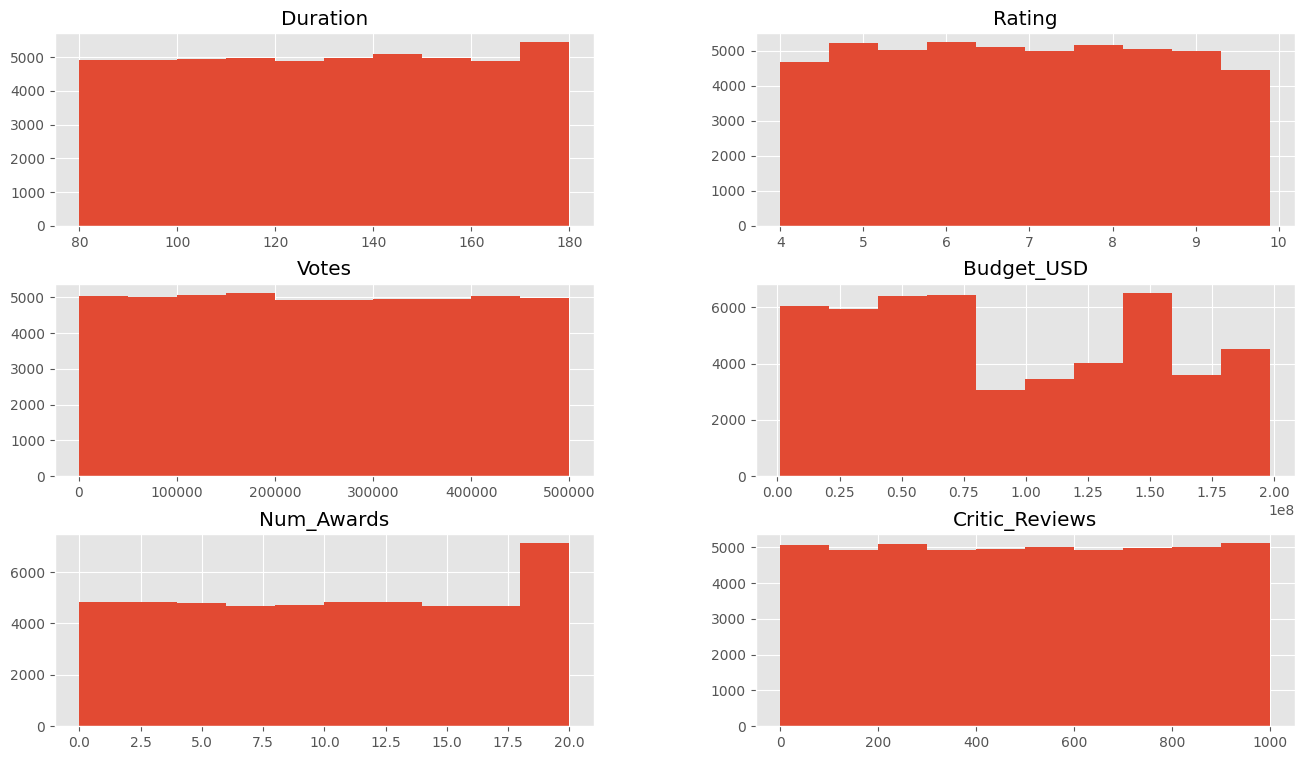

In [2]:
# Visualización del conjunto de datos
# Eliminamos las columnas que no se usaran y generamos un histograma de las que si
df.drop(['Title','Year', 'Director', 'Description','Language','Country','BoxOffice_USD','Genre','Production_Company','Content_Rating','Lead_Actor'],axis=1).hist()
# visualizamos el grafico
plt.show()

In [3]:
# Modificación del conjutno de datos

# Filtrado inicial, solo columnas relevantes
filtered_data = df[['Budget_USD', 'Duration', 'Rating', 'Votes', 'Num_Awards', 'Critic_Reviews', 'BoxOffice_USD']].copy()

# Eliminar filas con valores nulos
filtered_data = filtered_data.dropna()

#Codigo generado por chatgpt

# Eliminar outliers simples: limitar Votes y Budget_USD al percentil 95
Q95_votes = filtered_data['Votes'].quantile(0.95)
Q95_budget = filtered_data['Budget_USD'].quantile(0.95)
Q95_boxoffice = filtered_data['BoxOffice_USD'].quantile(0.95)

filtered_data = filtered_data[
    (filtered_data['Votes'] <= Q95_votes) &
    (filtered_data['Budget_USD'] <= Q95_budget) &
    (filtered_data['BoxOffice_USD'] <= Q95_boxoffice)
]

# Aplicar transformación logarítmica para variables con rangos grandes
filtered_data['Budget_USD_log'] = np.log1p(filtered_data['Budget_USD'])
filtered_data['Votes_log'] = np.log1p(filtered_data['Votes'])
filtered_data['BoxOffice_USD_log'] = np.log1p(filtered_data['BoxOffice_USD'])

#Codigo generado por mi

# variables x transformada
X = filtered_data[['Budget_USD_log', 'Duration', 'Rating', 'Votes_log', 'Num_Awards', 'Critic_Reviews']].values

# variable y transformada
y = filtered_data['BoxOffice_USD_log'].values

Coeficientes: 
 [ 4.13233467e-03 -2.95317536e-04  9.62100932e-04 -2.89258373e-03
  8.39314500e-04 -1.96605464e-05]


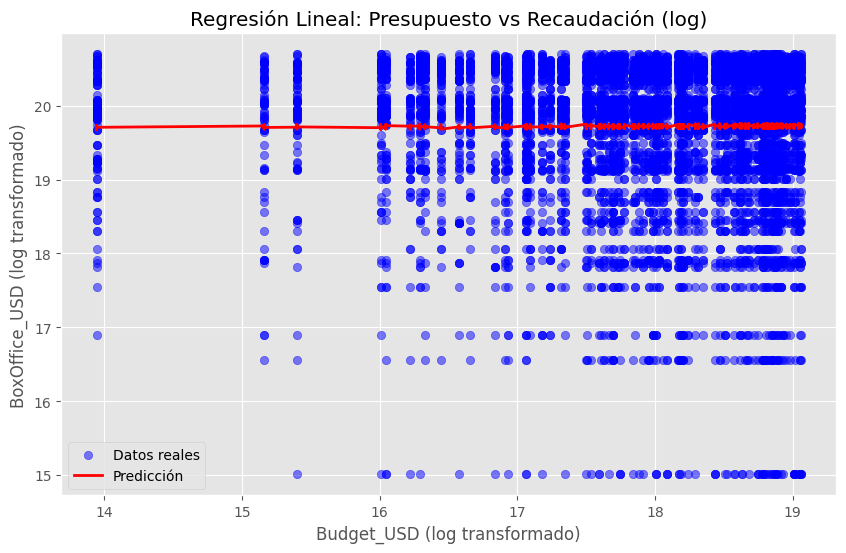

In [4]:
#Construcción del modelo de regresión lineal
# separamos prueba y entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# creamos y entrenamos el modelo
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

# predecimos
y_pred = model.predict(X_test)

# evaluamos
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Coeficientes: \n', model.coef_)

# Codigo de chatgpt
# Gráfica: Dispersión de Budget_USD_log vs BoxOffice_USD_log (test) y línea de predicción

plt.figure(figsize=(10,6))
# puntos reales
plt.scatter(X_test[:,0], y_test, color='blue', alpha=0.5, label='Datos reales')
# línea predicción (ordenar para graficar línea)
sort_idx = np.argsort(X_test[:,0])
plt.plot(X_test[sort_idx, 0], y_pred[sort_idx], color='red', linewidth=2, label='Predicción')

plt.xlabel('Budget_USD (log transformado)')
plt.ylabel('BoxOffice_USD (log transformado)')
plt.title('Regresión Lineal: Presupuesto vs Recaudación (log)')
plt.legend()
plt.show()

In [5]:
# Predicción de nuevos ejemplos

# funcion para pedir entrada numérica al usuario
def pedir_numero(mensaje, tipo=float):
    while True:
        try:
            return tipo(input(mensaje))
        except ValueError:
            print("Por favor, ingresa un número válido.")

# pedimos datos al usuario
budget = pedir_numero("Ingrese el presupuesto en USD: ")
duration = pedir_numero("Ingrese la duración en minutos: ", int)
rating = pedir_numero("Ingrese la calificación promedio: ")
votes = pedir_numero("Ingrese el número de votos: ", int)
num_awards = pedir_numero("Ingrese el número de premios obtenidos: ", int)
critic_reviews = pedir_numero("Ingrese el número de reseñas de críticos: ", int)

# Codigo de chatgpt

# Aplicar transformaciones logarítmicas
budget_log = np.log1p(budget)
votes_log = np.log1p(votes)

# Crear array para predicción
X_input = np.array([[budget_log, duration, rating, votes_log, num_awards, critic_reviews]])

# Predecir log(BoxOffice)
y_log_pred = model.predict(X_input)

# Volver a escala original
box_office_pred = np.expm1(y_log_pred)[0]

print(f"\nPredicción de recaudación en taquilla (BoxOffice_USD): ${box_office_pred:,.2f}")

Ingrese el presupuesto en USD:  1800000
Ingrese la duración en minutos:  93
Ingrese la calificación promedio:  2
Ingrese el número de votos:  51300
Ingrese el número de premios obtenidos:  2
Ingrese el número de reseñas de críticos:  4813



Predicción de recaudación en taquilla (BoxOffice_USD): $333,349,398.79
